<a href="https://colab.research.google.com/github/Harshitha-hunny/part1/blob/main/eda_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
web_events=pd.read_csv("/content/drive/MyDrive/T2_Project_harshitha /d2c churn data package/web_events_snapshot.csv")
churn=pd.read_csv("/content/drive/MyDrive/T2_Project_harshitha /d2c churn data package/churn_labels.csv")
customer=pd.read_csv("/content/drive/MyDrive/T2_Project_harshitha /d2c churn data package/customers.csv")
intervention=pd.read_csv("/content/drive/MyDrive/T2_Project_harshitha /d2c churn data package/intervention_history.csv")
orders=pd.read_csv("/content/drive/MyDrive/T2_Project_harshitha /d2c churn data package/orders.csv")
support=pd.read_csv("/content/drive/MyDrive/T2_Project_harshitha /d2c churn data package/support_tickets.csv")
rmf=pd.read_csv("/content/drive/MyDrive/T2_Project_harshitha /d2c churn data package/rfm_modeling_snapshot.csv")


In [36]:
dfs = {
    'web_events': web_events,
    'churn': churn,
    'customer': customer,
    'intervention': intervention,
    'orders': orders,
    'support': support,
    'rmf': rmf
}


In [37]:
for name, df in dfs.items():
    print(f"- {name}: Shape {df.shape}")
    print(df.info())

    print("\n")

- web_events: Shape (2400, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   snapshot_date        2400 non-null   object
 2   sessions_30d         2400 non-null   int64 
 3   product_views_30d    2400 non-null   int64 
 4   cart_adds_30d        2400 non-null   int64 
 5   wishlist_adds_30d    2400 non-null   int64 
 6   abandoned_carts_30d  2400 non-null   int64 
 7   email_opens_30d      2400 non-null   int64 
 8   campaign_clicks_30d  2400 non-null   int64 
 9   last_visit_days_ago  2400 non-null   int64 
dtypes: int64(8), object(2)
memory usage: 187.6+ KB
None


- churn: Shape (2400, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ---

Create a clear data-quality report covering missing values, duplicate-like records, outliers, invalid values, and join issues.

>>missing values

In [38]:
for name, df in dfs.items():
    print(f" Missing Values in {name}:")
    missing_values = df.isnull().sum()
    print(missing_values)


 Missing Values in web_events:
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_clicks_30d    0
last_visit_days_ago    0
dtype: int64
 Missing Values in churn:
customer_id       0
snapshot_date     0
churn_next_60d    0
split             0
dtype: int64
 Missing Values in customer:
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64
 Missing Values in intervention:
customer_id               0
snapshot_date             0
last_campaign_received    0
last_campaign_cost        0
manual_priority_bucket    0
dtype: int64
 Missing Values in orders:
order_id          0
customer_id       0
order_date        0
category          0


In [39]:
default_tier = 'Bronze'
rmf['loyalty_tier'] = rmf['loyalty_tier'].fillna(value=default_tier)

In [40]:
default_tier = 'Bronze'
customer['loyalty_tier'] = customer['loyalty_tier'].fillna(value=default_tier)
customer['skin_type'] = customer['skin_type'].fillna('unknown')

In [41]:
orders['rating']=orders['rating'].fillna(value=orders['rating'].mean())

In [42]:
for name, df in dfs.items():
    print(f" Missing Values in {name}:")
    missing_values = df.isnull().sum()
    print(missing_values)

 Missing Values in web_events:
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_clicks_30d    0
last_visit_days_ago    0
dtype: int64
 Missing Values in churn:
customer_id       0
snapshot_date     0
churn_next_60d    0
split             0
dtype: int64
 Missing Values in customer:
customer_id            0
signup_date            0
city_tier              0
age_group              0
acquisition_channel    0
loyalty_tier           0
preferred_category     0
skin_type              0
marketing_consent      0
dtype: int64
 Missing Values in intervention:
customer_id               0
snapshot_date             0
last_campaign_received    0
last_campaign_cost        0
manual_priority_bucket    0
dtype: int64
 Missing Values in orders:
order_id         0
customer_id      0
order_date       0
category         0
quantity         0
gross_amount

>>duplicate records

In [43]:
for name, df in dfs.items():
    print(f" Duplicate Records {name}:")
    num = df.duplicated().sum()
    print(f" {num} duplicate rows.")

 Duplicate Records web_events:
 0 duplicate rows.
 Duplicate Records churn:
 0 duplicate rows.
 Duplicate Records customer:
 0 duplicate rows.
 Duplicate Records intervention:
 0 duplicate rows.
 Duplicate Records orders:
 0 duplicate rows.
 Duplicate Records support:
 0 duplicate rows.
 Duplicate Records rmf:
 0 duplicate rows.


>>snapshot date

In [44]:
orders['order_date']=pd.to_datetime(orders['order_date'])
cutoff_date = pd.to_datetime('2025-09-30')
orders = orders[orders['order_date'] <= cutoff_date]
print(orders.shape)

(8137, 10)


>>outliers


In [45]:
for name, df in dfs.items():
    print(f"Invalid/Unusual Values & Outliers in {name}:\n")
    for col in df.columns:
        if np.issubdtype(df[col].dtype, np.number):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
            print(f"    - {col}: Potential outliers: {outliers} ")

Invalid/Unusual Values & Outliers in web_events:

    - sessions_30d: Potential outliers: 27 
    - product_views_30d: Potential outliers: 46 
    - cart_adds_30d: Potential outliers: 77 
    - wishlist_adds_30d: Potential outliers: 180 
    - abandoned_carts_30d: Potential outliers: 108 
    - email_opens_30d: Potential outliers: 2 
    - campaign_clicks_30d: Potential outliers: 128 
    - last_visit_days_ago: Potential outliers: 0 
Invalid/Unusual Values & Outliers in churn:

    - churn_next_60d: Potential outliers: 0 
Invalid/Unusual Values & Outliers in customer:

Invalid/Unusual Values & Outliers in intervention:

    - last_campaign_cost: Potential outliers: 0 
Invalid/Unusual Values & Outliers in orders:

    - quantity: Potential outliers: 247 
    - gross_amount: Potential outliers: 536 
    - discount_pct: Potential outliers: 47 
    - delivery_days: Potential outliers: 3 
    - returned: Potential outliers: 675 
    - rating: Potential outliers: 0 
Invalid/Unusual Values & 

>>Join/Key Issues

In [46]:
for name, df in dfs.items():
    print(f"#### Join/Key Issues in {name}:\n")
    if 'customer_id' in df.columns:
        if df['customer_id'].duplicated().any():
            print(f"  - `customer_id` is not unique in {name}")
        else:
            print(f"  - `customer_id` is unique in {name}")
    if 'order_id' in df.columns:
        if df['order_id'].duplicated().any():
            print(f"  - `order_id` is not unique in {name}")
        else:
            print(f"  - `order_id` is unique in {name}")
    if 'ticket_id' in df.columns:
        if df['ticket_id'].duplicated().any():
            print(f"  - `ticket_id` is not unique in {name}")
        else:
            print(f"  - `ticket_id` is unique in {name}")



#### Join/Key Issues in web_events:

  - `customer_id` is unique in web_events
#### Join/Key Issues in churn:

  - `customer_id` is unique in churn
#### Join/Key Issues in customer:

  - `customer_id` is unique in customer
#### Join/Key Issues in intervention:

  - `customer_id` is unique in intervention
#### Join/Key Issues in orders:

  - `customer_id` is not unique in orders
  - `order_id` is unique in orders
#### Join/Key Issues in support:

  - `customer_id` is not unique in support
  - `ticket_id` is unique in support
#### Join/Key Issues in rmf:

  - `customer_id` is unique in rmf


 Potential Data Leakage in churn:
    `churn_next_60d` is the target variable. Other features should be constructed such that they are known *before* this target period
    
Potential Data Leakage in rmf:
    `churn_next_60d` is present, ensure it's removed if this dataframe is used for feature engineering
    Features like `recency_days`, `frequency_180d`, `monetary_180d`, etc., are aggregated up to `snapshot_date` and seem appropriate for prediction
   

In [47]:
# Convert all relevant date columns to datetime objects if not already
for df_name in ['customer', 'orders', 'web_events', 'churn', 'intervention', 'rmf', 'support']:
    df_obj = dfs[df_name]
    for col in df_obj.columns:
        if 'date' in col and df_obj[col].dtype == 'object':
            try:
                dfs[df_name][col] = pd.to_datetime(df_obj[col])
            except Exception as e:
                print(f"  - Warning: Could not convert {df_name}[{col}] to datetime: {e}")

In [48]:

print("#### Customer ID Consistency Across DataFrames:\n")
customer_ids_master = set(customer['customer_id'].unique())
for name, df in dfs.items():
    if name != 'customer' and 'customer_id' in df.columns:
        df_customer_ids = set(df['customer_id'].unique())
        not_in_master = df_customer_ids - customer_ids_master
        if not_in_master:
            print(f"  - **{name.capitalize()}**: {len(not_in_master)} `customer_id`s present in `{name}` but not in `customer` master list. Example: {list(not_in_master)[:5]}")
        else:
            print(f"  - **{name.capitalize()}**: All `customer_id`s are present in `customer` master list.")
print("\n")


#### Customer ID Consistency Across DataFrames:

  - **Web_events**: All `customer_id`s are present in `customer` master list.
  - **Churn**: All `customer_id`s are present in `customer` master list.
  - **Intervention**: All `customer_id`s are present in `customer` master list.
  - **Orders**: All `customer_id`s are present in `customer` master list.
  - **Support**: All `customer_id`s are present in `customer` master list.
  - **Rmf**: All `customer_id`s are present in `customer` master list.




## Exploratory Data Analysis (EDA)

### 1. Customer Demographics and Profile Analysis

/tmp/ipykernel_7901/1650981564.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer, x='city_tier', palette='viridis', order=customer['city_tier'].value_counts().index)


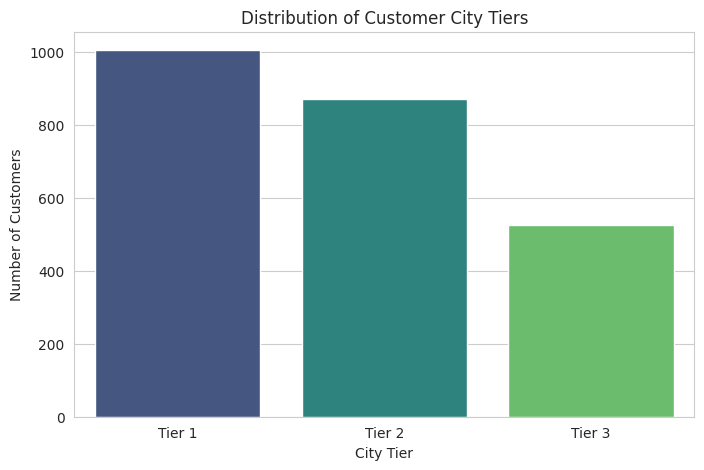

/tmp/ipykernel_7901/1650981564.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer, x='age_group', palette='viridis', order=customer['age_group'].value_counts().index)


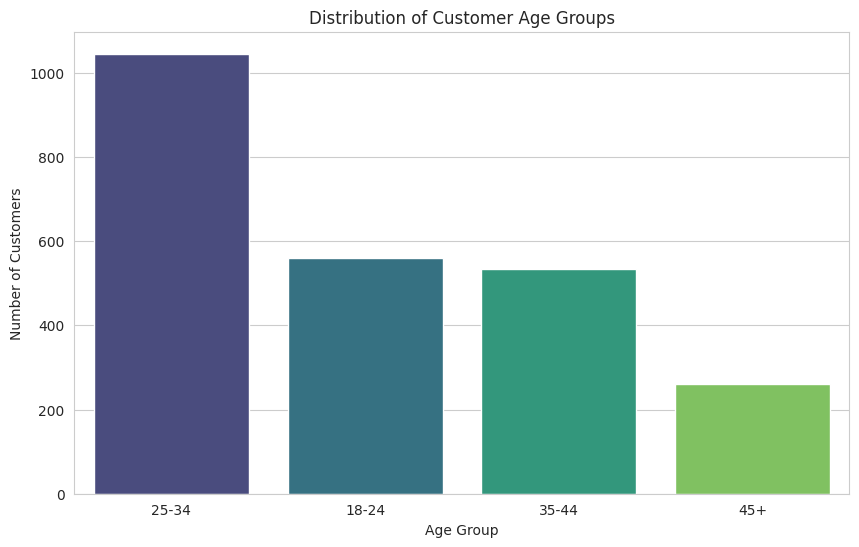

/tmp/ipykernel_7901/1650981564.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer, y='acquisition_channel', palette='plasma', order=customer['acquisition_channel'].value_counts().index)


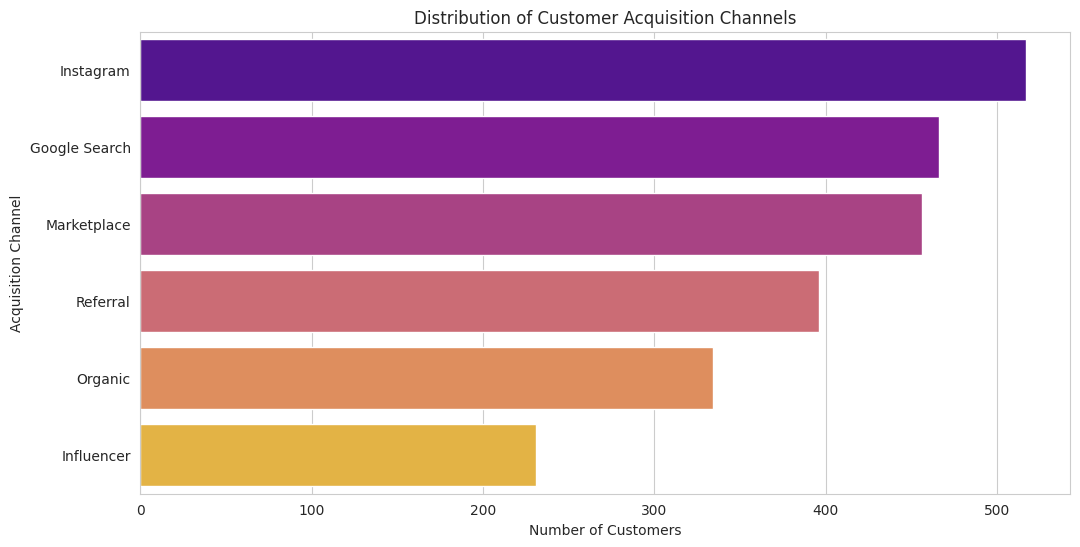

/tmp/ipykernel_7901/1650981564.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer, x='loyalty_tier', palette='plasma', order=customer['loyalty_tier'].value_counts().index)


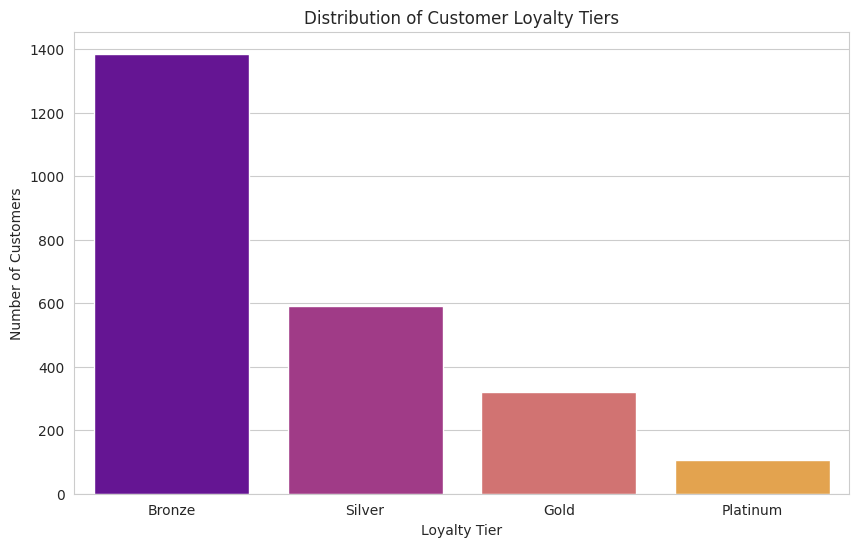

/tmp/ipykernel_7901/1650981564.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer, y='preferred_category', palette='viridis', order=customer['preferred_category'].value_counts().index)


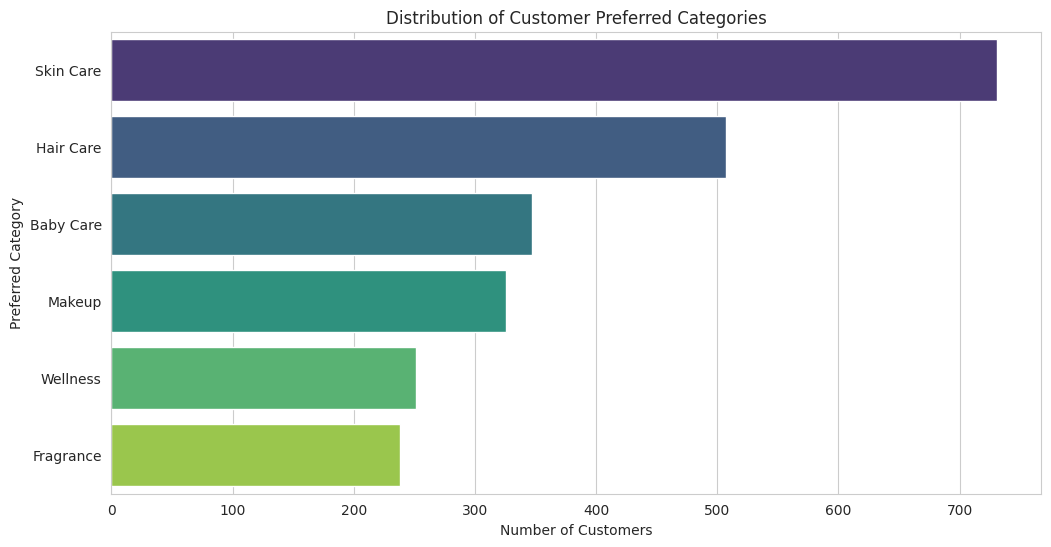

/tmp/ipykernel_7901/1650981564.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer, x='skin_type', palette='viridis', order=customer['skin_type'].value_counts().index)


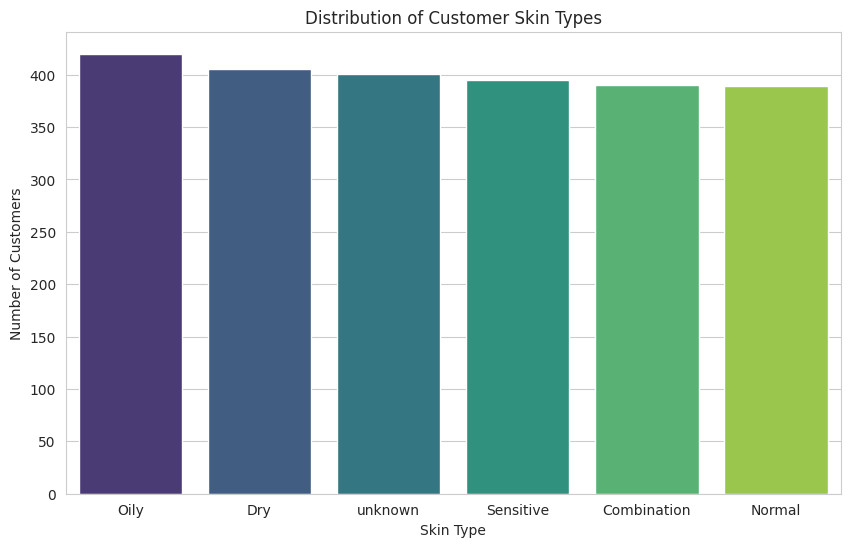

/tmp/ipykernel_7901/1650981564.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer, x='marketing_consent', palette='viridis')


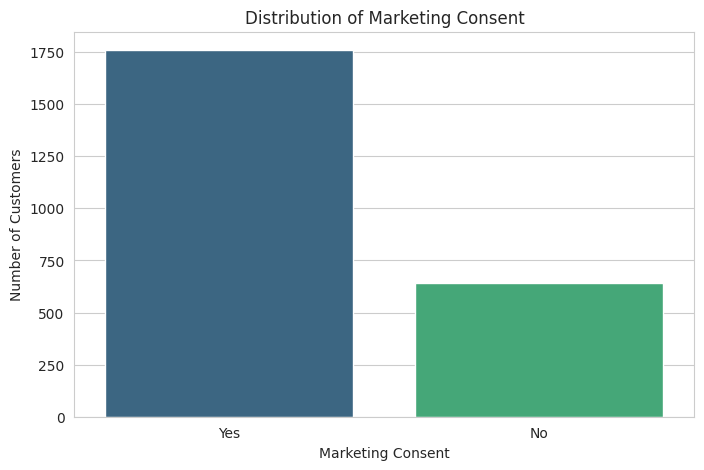

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Analyze City Tier Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=customer, x='city_tier', palette='viridis', order=customer['city_tier'].value_counts().index)
plt.title('Distribution of Customer City Tiers')
plt.xlabel('City Tier')
plt.ylabel('Number of Customers')
plt.show()

# Analyze Age Group Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=customer, x='age_group', palette='viridis', order=customer['age_group'].value_counts().index)
plt.title('Distribution of Customer Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

# Analyze Acquisition Channel Distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=customer, y='acquisition_channel', palette='plasma', order=customer['acquisition_channel'].value_counts().index)
plt.title('Distribution of Customer Acquisition Channels')
plt.xlabel('Number of Customers')
plt.ylabel('Acquisition Channel')
plt.show()

# Analyze Loyalty Tier Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=customer, x='loyalty_tier', palette='plasma', order=customer['loyalty_tier'].value_counts().index)
plt.title('Distribution of Customer Loyalty Tiers')
plt.xlabel('Loyalty Tier')
plt.ylabel('Number of Customers')
plt.show()

# Analyze Preferred Category Distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=customer, y='preferred_category', palette='viridis', order=customer['preferred_category'].value_counts().index)
plt.title('Distribution of Customer Preferred Categories')
plt.xlabel('Number of Customers')
plt.ylabel('Preferred Category')
plt.show()

# Analyze Skin Type Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=customer, x='skin_type', palette='viridis', order=customer['skin_type'].value_counts().index)
plt.title('Distribution of Customer Skin Types')
plt.xlabel('Skin Type')
plt.ylabel('Number of Customers')
plt.show()

# Analyze Marketing Consent Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=customer, x='marketing_consent', palette='viridis')
plt.title('Distribution of Marketing Consent')
plt.xlabel('Marketing Consent')
plt.ylabel('Number of Customers')
plt.show()

### 2. Churn Distribution Analysis

/tmp/ipykernel_7901/1702730701.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=churn, x='churn_next_60d', palette='coolwarm')


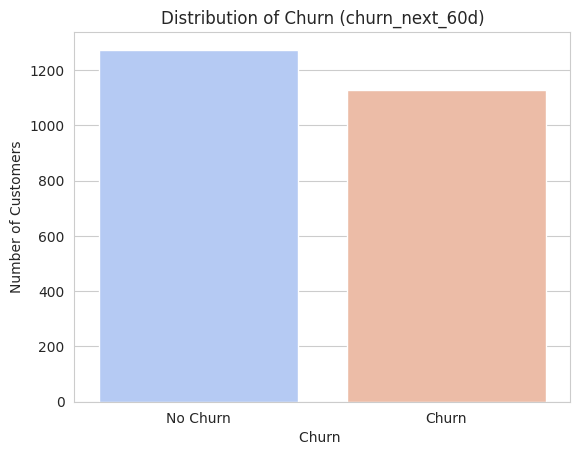

Churn Distribution:
churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64


In [49]:
sns.countplot(data=churn, x='churn_next_60d', palette='coolwarm')
plt.title('Distribution of Churn (churn_next_60d)')
plt.xlabel('Churn ')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

churn_percentage = churn['churn_next_60d'].value_counts(normalize=True) * 100
print("Churn Distribution:")
print(churn_percentage)

### 3. Order Behavior Analysis

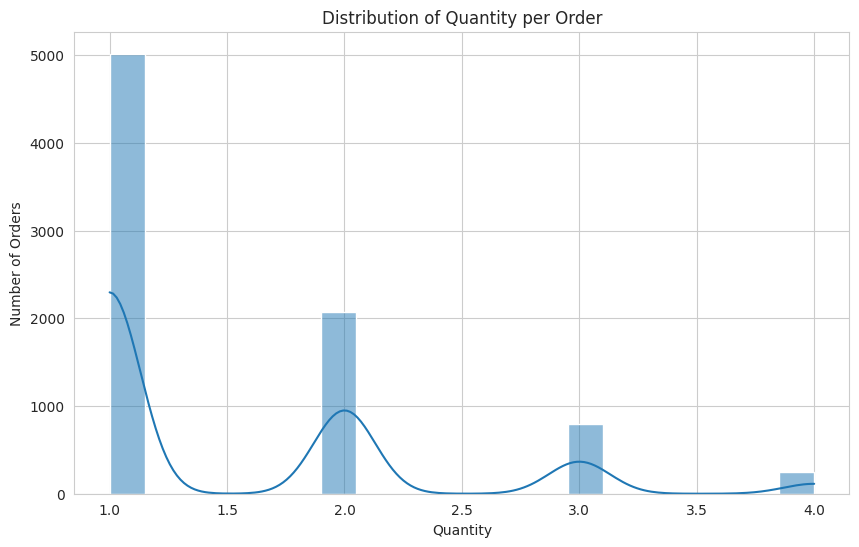

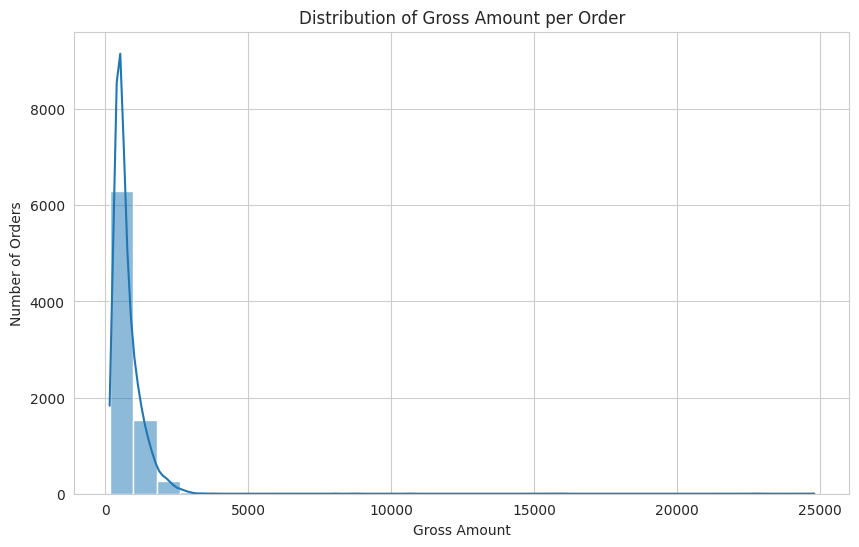

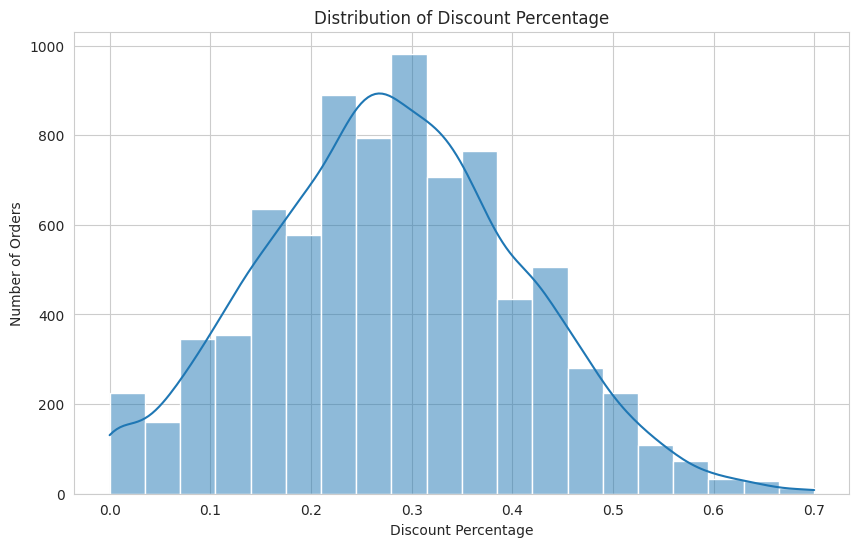

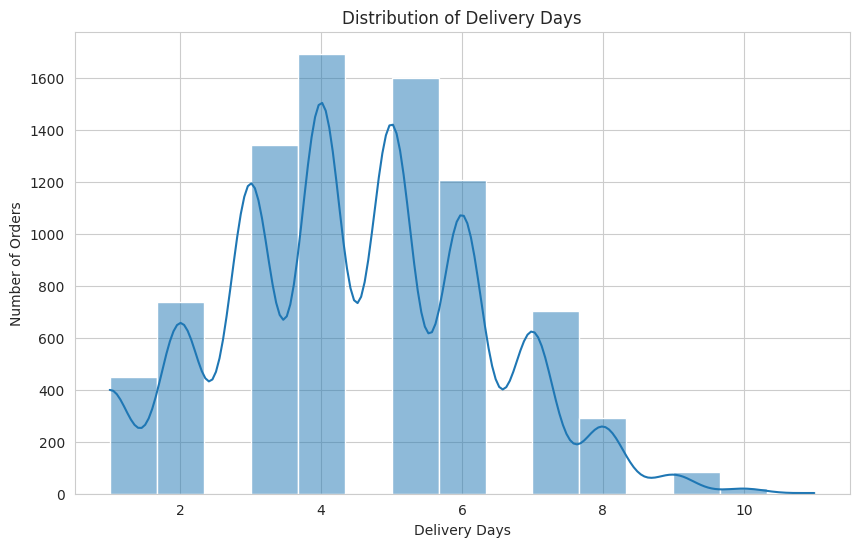

/tmp/ipykernel_7901/3354143738.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=orders, x='returned', palette='pastel')


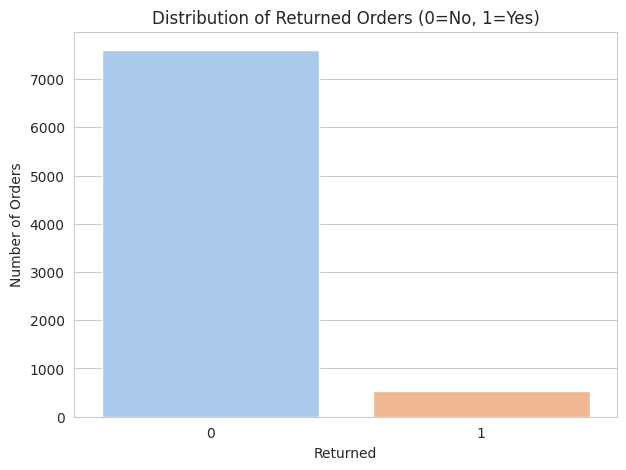

/tmp/ipykernel_7901/3354143738.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=orders, x='rating', palette='cool')


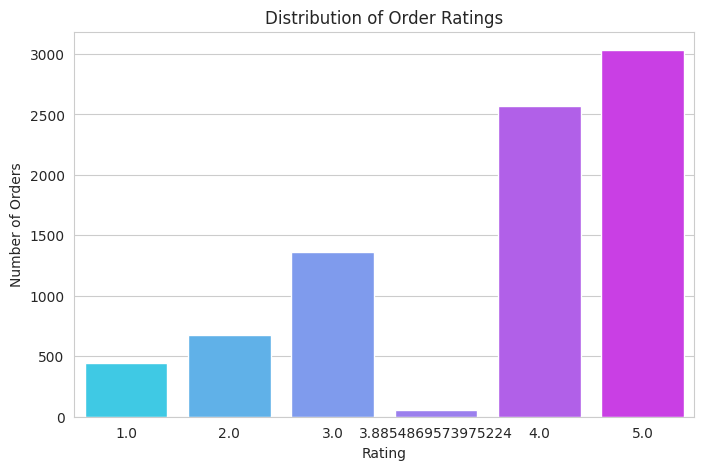

In [50]:

# Distribution of Quantity per order
plt.figure(figsize=(10, 6))
sns.histplot(orders['quantity'], bins=20, kde=True)
plt.title('Distribution of Quantity per Order')
plt.xlabel('Quantity')
plt.ylabel('Number of Orders')
plt.show()

# Distribution of Gross Amount per order
plt.figure(figsize=(10, 6))
sns.histplot(orders['gross_amount'], bins=30, kde=True)
plt.title('Distribution of Gross Amount per Order')
plt.xlabel('Gross Amount')
plt.ylabel('Number of Orders')
plt.show()

# Distribution of Discount Percentage
plt.figure(figsize=(10, 6))
sns.histplot(orders['discount_pct'], bins=20, kde=True)
plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount Percentage')
plt.ylabel('Number of Orders')
plt.show()

# Distribution of Delivery Days
plt.figure(figsize=(10, 6))
sns.histplot(orders['delivery_days'], bins=15, kde=True)
plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.show()

# Distribution of Returned Orders
plt.figure(figsize=(7, 5))
sns.countplot(data=orders, x='returned', palette='pastel')
plt.title('Distribution of Returned Orders (0=No, 1=Yes)')
plt.xlabel('Returned')
plt.ylabel('Number of Orders')
plt.show()

# Distribution of Ratings
plt.figure(figsize=(8, 5))
sns.countplot(data=orders, x='rating', palette='cool')
plt.title('Distribution of Order Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')
plt.show()

### 4. Monetary Behavior Analysis

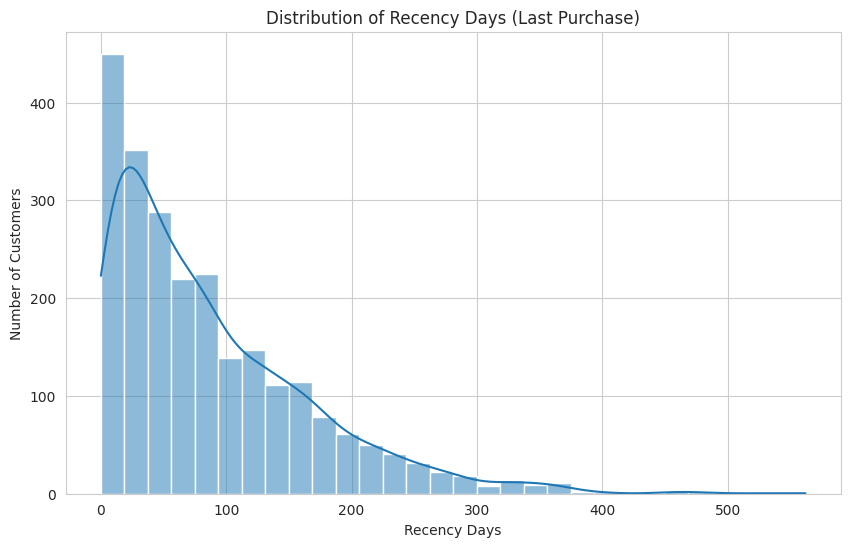

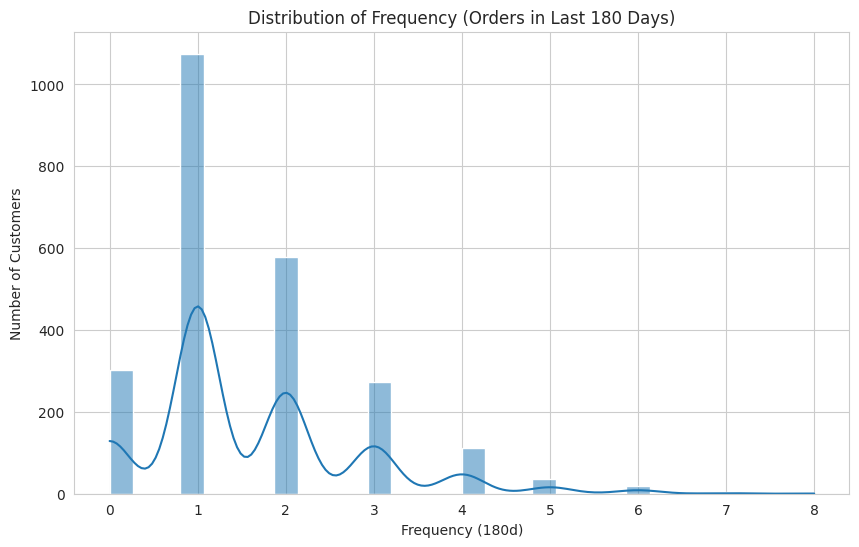

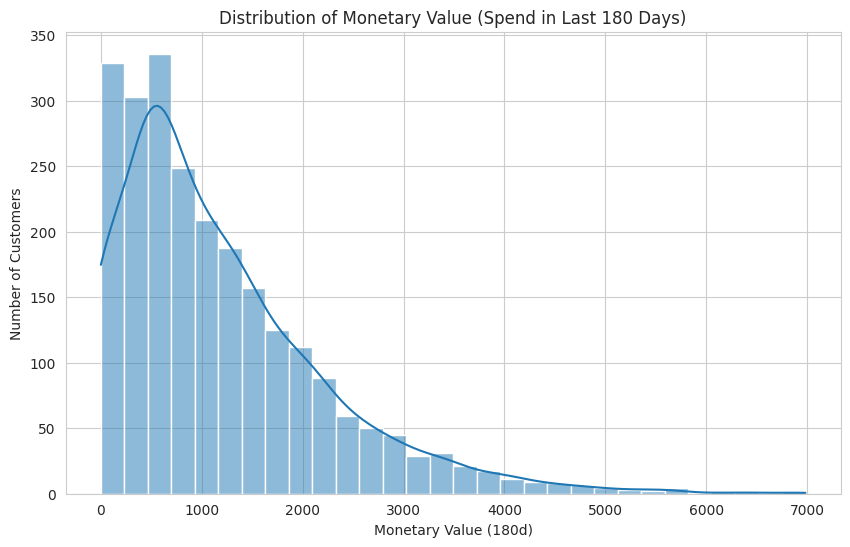

In [51]:

# Distribution of Recency Days
plt.figure(figsize=(10, 6))
sns.histplot(rmf['recency_days'], bins=30, kde=True)
plt.title('Distribution of Recency Days (Last Purchase)')
plt.xlabel('Recency Days')
plt.ylabel('Number of Customers')
plt.show()

# Distribution of Frequency (180 days)
plt.figure(figsize=(10, 6))
sns.histplot(rmf['frequency_180d'], bins=30, kde=True)
plt.title('Distribution of Frequency (Orders in Last 180 Days)')
plt.xlabel('Frequency (180d)')
plt.ylabel('Number of Customers')
plt.show()

# Distribution of Monetary Value (180 days)
plt.figure(figsize=(10, 6))
sns.histplot(rmf['monetary_180d'], bins=30, kde=True)
plt.title('Distribution of Monetary Value (Spend in Last 180 Days)')
plt.xlabel('Monetary Value (180d)')
plt.ylabel('Number of Customers')
plt.show()



### 5. Support Ticket Issues Analysis

/tmp/ipykernel_7901/1455951219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=support, y='issue_type', palette='viridis', order=support['issue_type'].value_counts().index)


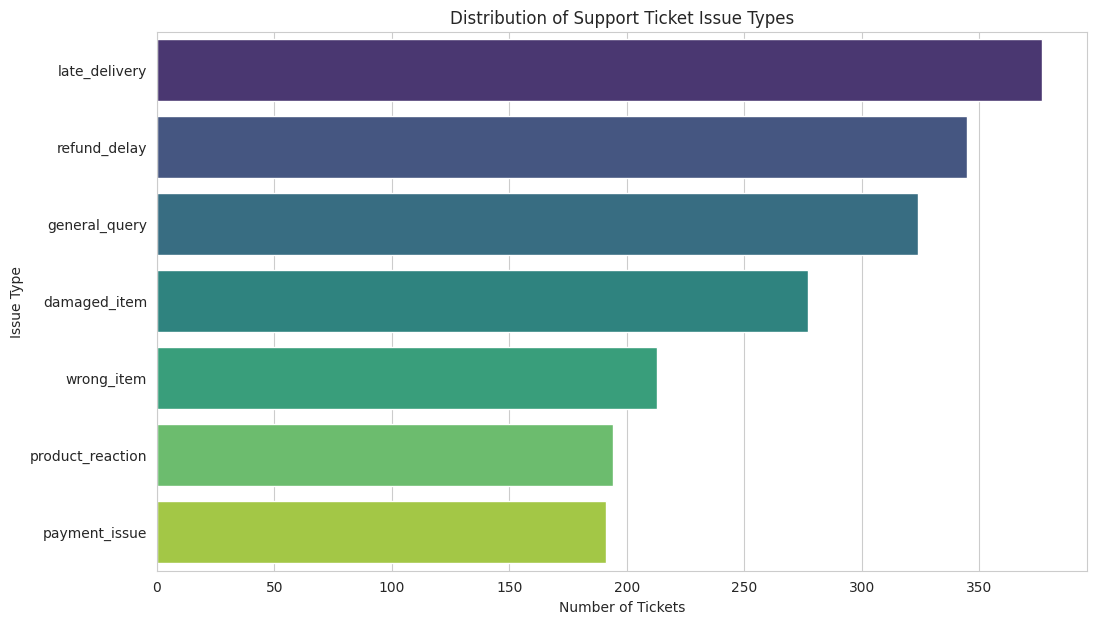

/tmp/ipykernel_7901/1455951219.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=support, x='support_channel', palette='magma', order=support['support_channel'].value_counts().index)


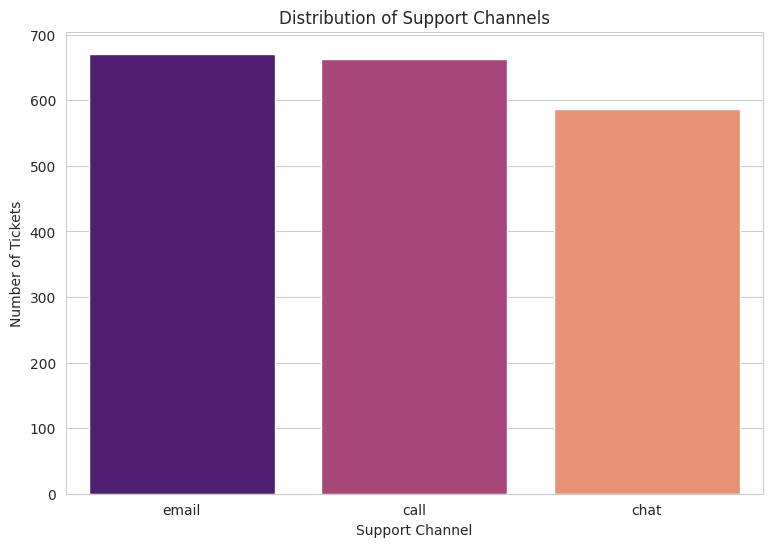

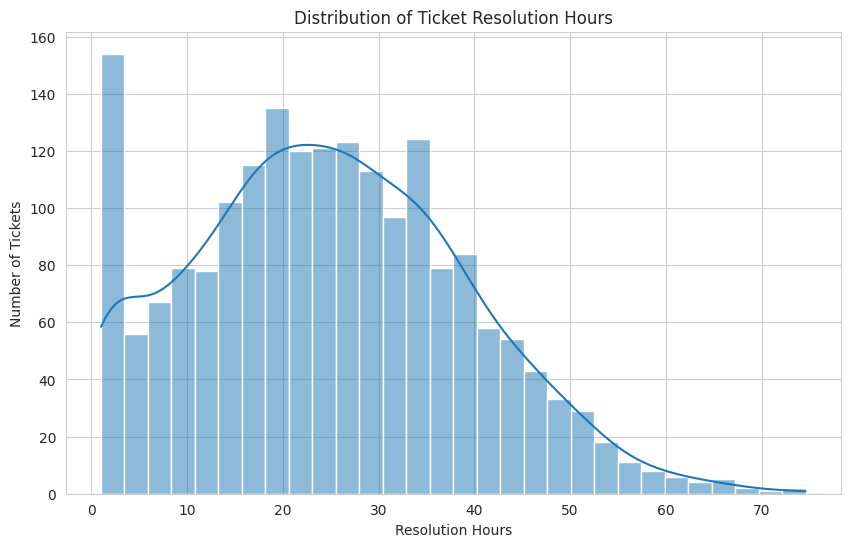

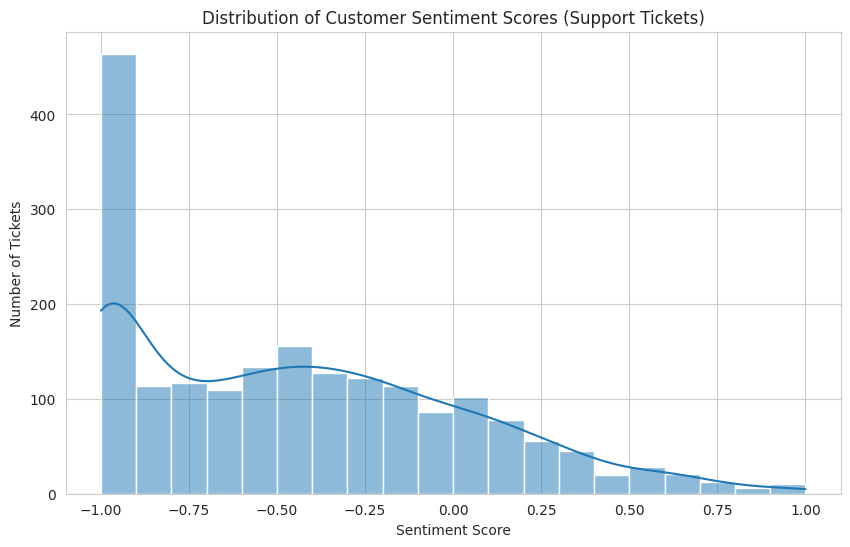

/tmp/ipykernel_7901/1455951219.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=support, x='reopened', palette='pastel')


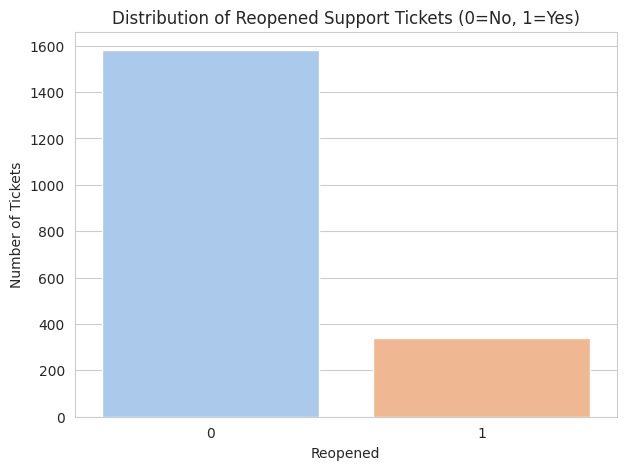

In [52]:

# Distribution of Issue Types
plt.figure(figsize=(12, 7))
sns.countplot(data=support, y='issue_type', palette='viridis', order=support['issue_type'].value_counts().index)
plt.title('Distribution of Support Ticket Issue Types')
plt.xlabel('Number of Tickets')
plt.ylabel('Issue Type')
plt.show()

# Distribution of Support Channels
plt.figure(figsize=(9, 6))
sns.countplot(data=support, x='support_channel', palette='magma', order=support['support_channel'].value_counts().index)
plt.title('Distribution of Support Channels')
plt.xlabel('Support Channel')
plt.ylabel('Number of Tickets')
plt.show()

# Distribution of Resolution Hours
plt.figure(figsize=(10, 6))
sns.histplot(support['resolution_hours'], bins=30, kde=True)
plt.title('Distribution of Ticket Resolution Hours')
plt.xlabel('Resolution Hours')
plt.ylabel('Number of Tickets')
plt.show()

# Distribution of Sentiment Scores
plt.figure(figsize=(10, 6))
sns.histplot(support['sentiment_score'], bins=20, kde=True)
plt.title('Distribution of Customer Sentiment Scores (Support Tickets)')
plt.xlabel('Sentiment Score')
plt.ylabel('Number of Tickets')
plt.show()

# Distribution of Reopened Tickets
plt.figure(figsize=(7, 5))
sns.countplot(data=support, x='reopened', palette='pastel')
plt.title('Distribution of Reopened Support Tickets (0=No, 1=Yes)')
plt.xlabel('Reopened')
plt.ylabel('Number of Tickets')
plt.show()

### 6. Return/Refund Behavior Analysis

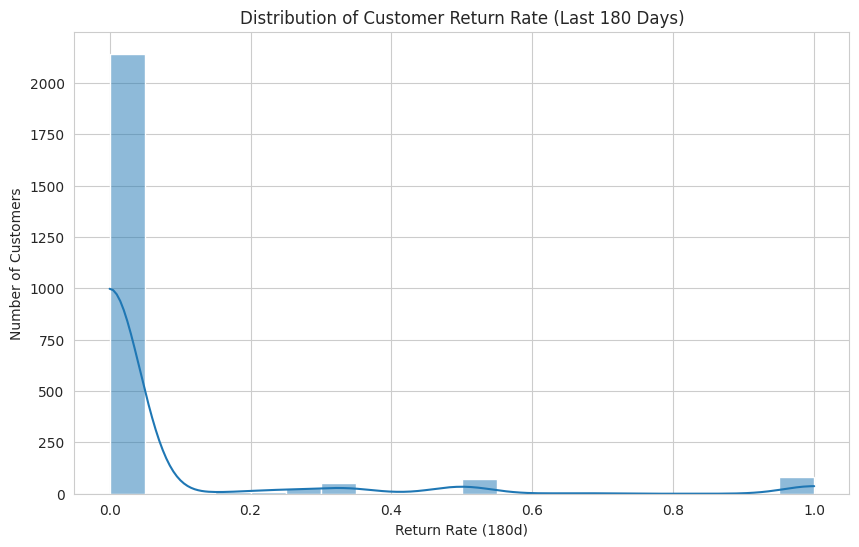

In [53]:

# Distribution of Return Rate (from rmf dataframe)
plt.figure(figsize=(10, 6))
sns.histplot(rmf['return_rate_180d'], bins=20, kde=True)
plt.title('Distribution of Customer Return Rate (Last 180 Days)')
plt.xlabel('Return Rate (180d)')
plt.ylabel('Number of Customers')
plt.show()

### 7. Web/App Activity Analysis

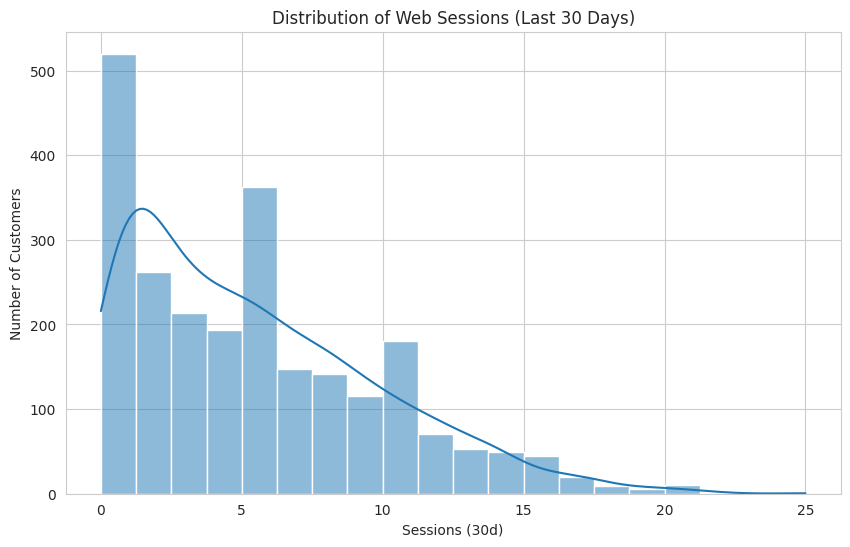

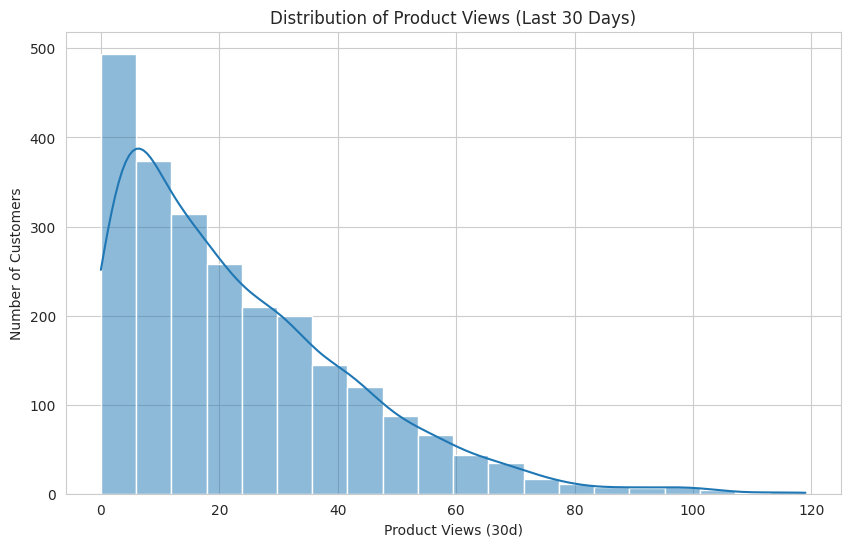

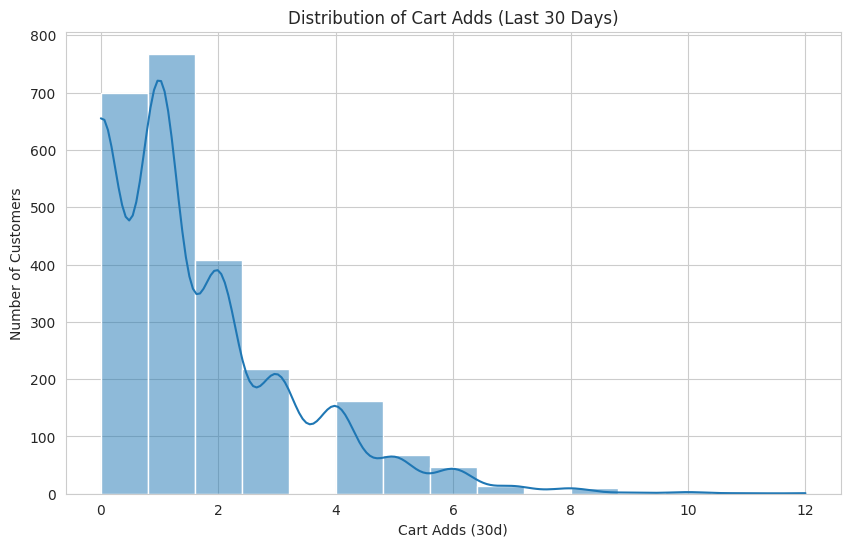

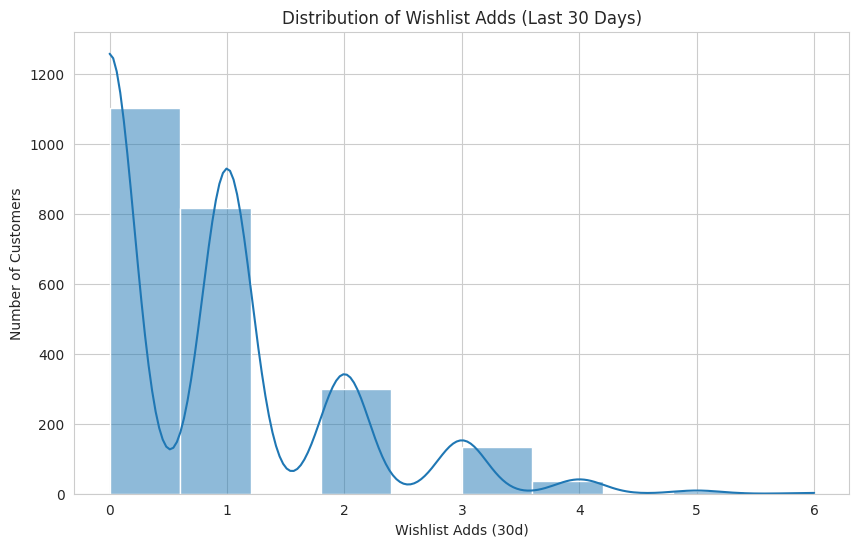

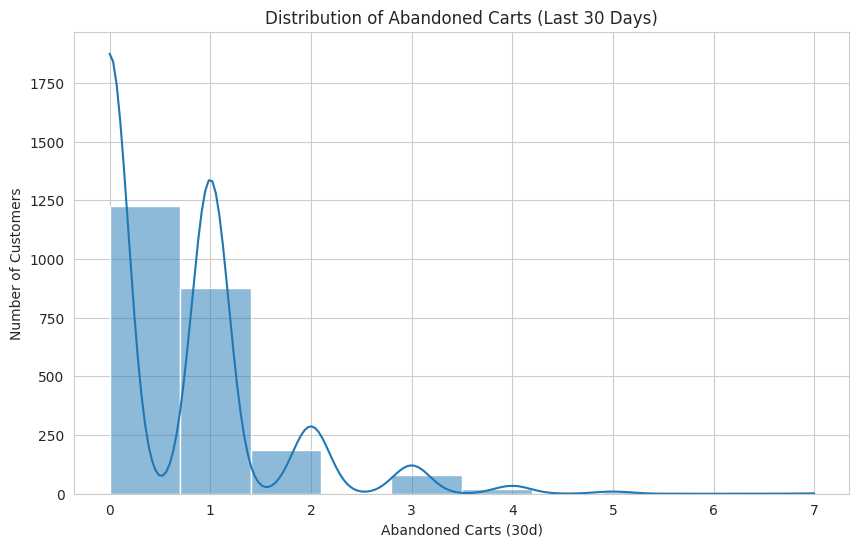

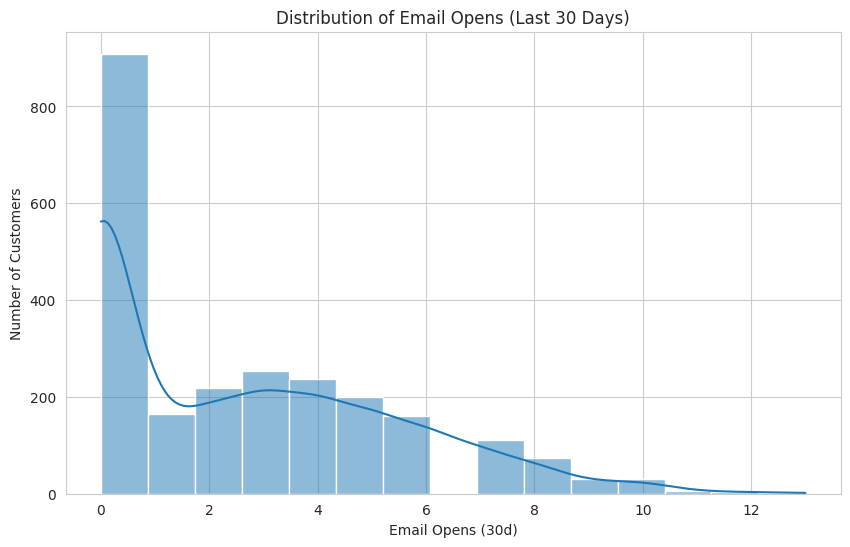

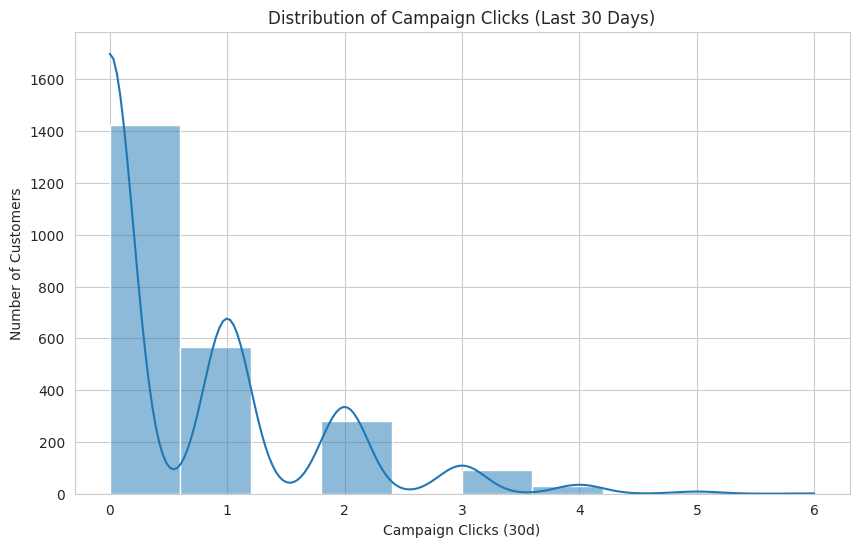

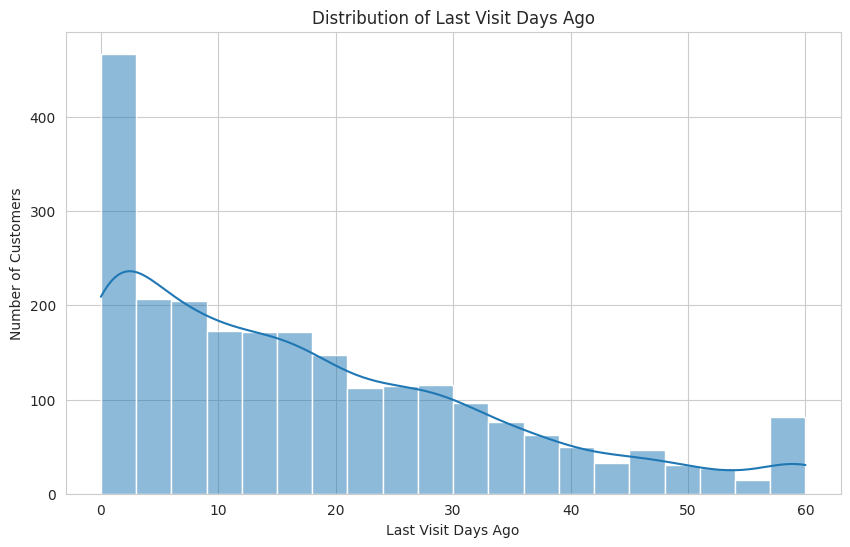

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Distribution of Sessions (30 days)
plt.figure(figsize=(10, 6))
sns.histplot(web_events['sessions_30d'], bins=20, kde=True)
plt.title('Distribution of Web Sessions (Last 30 Days)')
plt.xlabel('Sessions (30d)')
plt.ylabel('Number of Customers')
plt.show()

# Distribution of Product Views (30 days)
plt.figure(figsize=(10, 6))
sns.histplot(web_events['product_views_30d'], bins=20, kde=True)
plt.title('Distribution of Product Views (Last 30 Days)')
plt.xlabel('Product Views (30d)')
plt.ylabel('Number of Customers')
plt.show()

# Distribution of Cart Adds (30 days)
plt.figure(figsize=(10, 6))
sns.histplot(web_events['cart_adds_30d'], bins=15, kde=True)
plt.title('Distribution of Cart Adds (Last 30 Days)')
plt.xlabel('Cart Adds (30d)')
plt.ylabel('Number of Customers')
plt.show()

# Distribution of Wishlist Adds (30 days)
plt.figure(figsize=(10, 6))
sns.histplot(web_events['wishlist_adds_30d'], bins=10, kde=True)
plt.title('Distribution of Wishlist Adds (Last 30 Days)')
plt.xlabel('Wishlist Adds (30d)')
plt.ylabel('Number of Customers')
plt.show()

# Distribution of Abandoned Carts (30 days)
plt.figure(figsize=(10, 6))
sns.histplot(web_events['abandoned_carts_30d'], bins=10, kde=True)
plt.title('Distribution of Abandoned Carts (Last 30 Days)')
plt.xlabel('Abandoned Carts (30d)')
plt.ylabel('Number of Customers')
plt.show()

# Distribution of Email Opens (30 days)
plt.figure(figsize=(10, 6))
sns.histplot(web_events['email_opens_30d'], bins=15, kde=True)
plt.title('Distribution of Email Opens (Last 30 Days)')
plt.xlabel('Email Opens (30d)')
plt.ylabel('Number of Customers')
plt.show()

# Distribution of Campaign Clicks (30 days)
plt.figure(figsize=(10, 6))
sns.histplot(web_events['campaign_clicks_30d'], bins=10, kde=True)
plt.title('Distribution of Campaign Clicks (Last 30 Days)')
plt.xlabel('Campaign Clicks (30d)')
plt.ylabel('Number of Customers')
plt.show()

# Distribution of Last Visit Days Ago
plt.figure(figsize=(10, 6))
sns.histplot(web_events['last_visit_days_ago'], bins=20, kde=True)
plt.title('Distribution of Last Visit Days Ago')
plt.xlabel('Last Visit Days Ago')
plt.ylabel('Number of Customers')
plt.show()

### 8. Campaign or Intervention History Analysis

/tmp/ipykernel_7901/1813240451.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=intervention, y='last_campaign_received', palette='viridis', order=intervention['last_campaign_received'].value_counts().index)


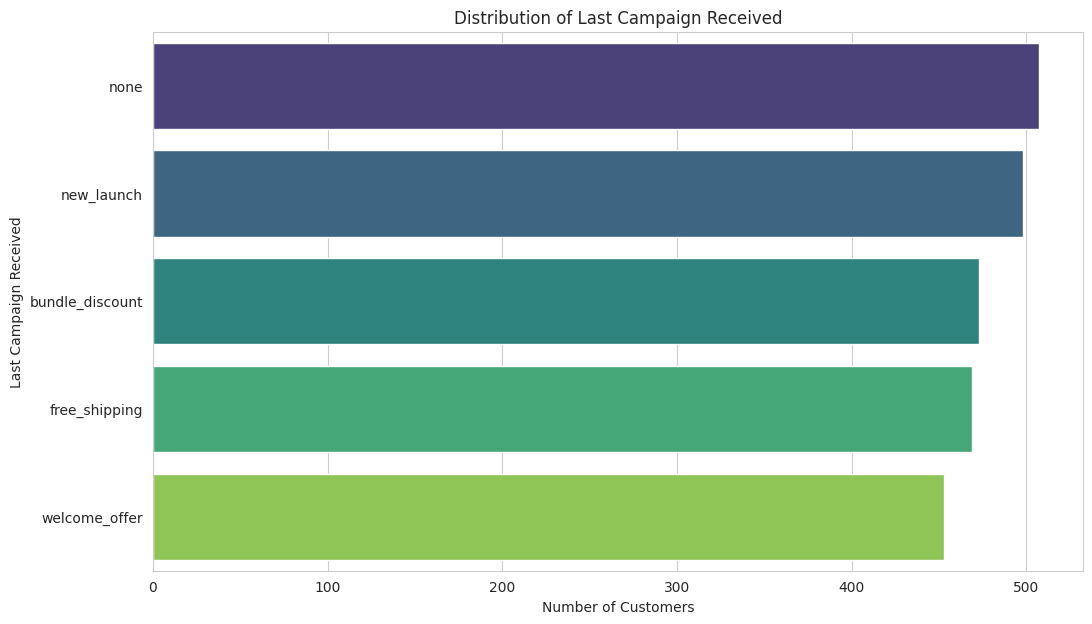

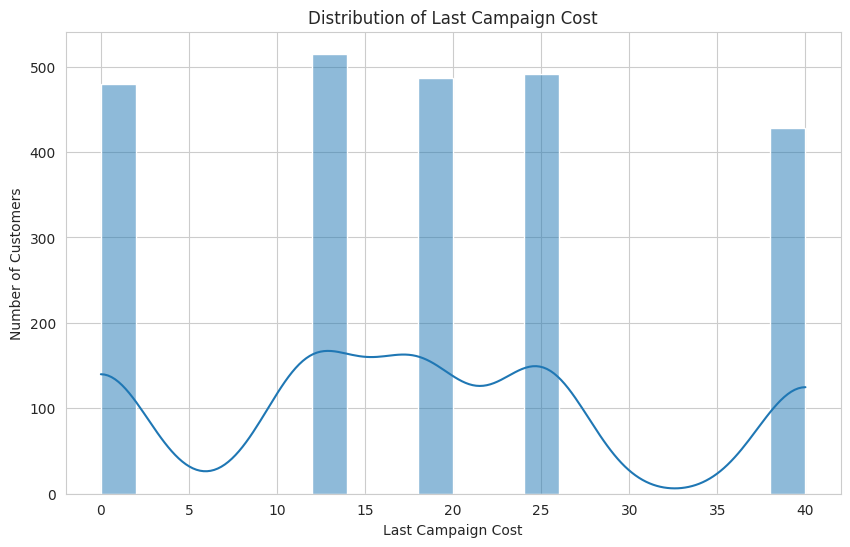

/tmp/ipykernel_7901/1813240451.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=intervention, x='manual_priority_bucket', palette='magma', order=intervention['manual_priority_bucket'].value_counts().index)


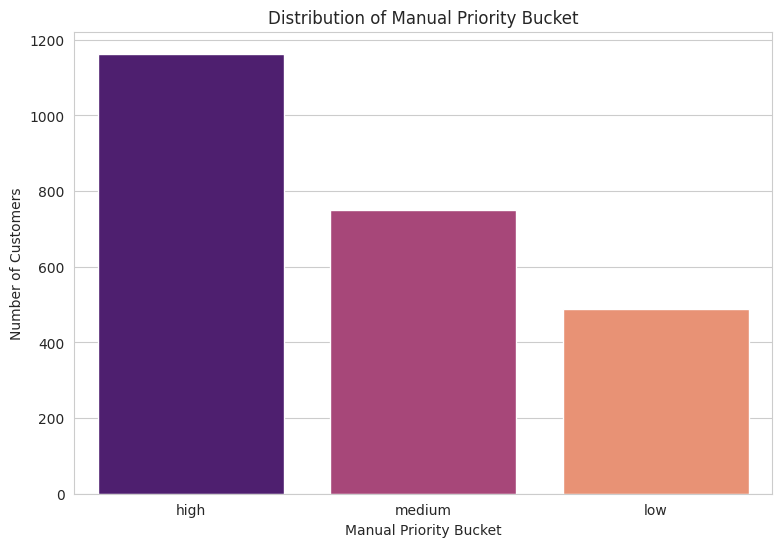

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Distribution of Last Campaign Received
plt.figure(figsize=(12, 7))
sns.countplot(data=intervention, y='last_campaign_received', palette='viridis', order=intervention['last_campaign_received'].value_counts().index)
plt.title('Distribution of Last Campaign Received')
plt.xlabel('Number of Customers')
plt.ylabel('Last Campaign Received')
plt.show()

# Distribution of Last Campaign Cost
plt.figure(figsize=(10, 6))
sns.histplot(intervention['last_campaign_cost'], bins=20, kde=True)
plt.title('Distribution of Last Campaign Cost')
plt.xlabel('Last Campaign Cost')
plt.ylabel('Number of Customers')
plt.show()

# Distribution of Manual Priority Bucket
plt.figure(figsize=(9, 6))
sns.countplot(data=intervention, x='manual_priority_bucket', palette='magma', order=intervention['manual_priority_bucket'].value_counts().index)
plt.title('Distribution of Manual Priority Bucket')
plt.xlabel('Manual Priority Bucket')
plt.ylabel('Number of Customers')
plt.show()

## Churn Risk Hypotheses

### Hypothesis 1: Customers with lower monetary value (lower spend in the last 180 days) are more likely to churn.

**Explanation:** The box plot and mean values clearly show that customers who churned (`churn_next_60d = 1`) have a significantly lower `monetary_180d` compared to those who did not churn. This suggests that customers spending less money are at a higher risk of churning.

/tmp/ipykernel_7901/2534372600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rmf, x='churn_next_60d', y='monetary_180d', palette='coolwarm')


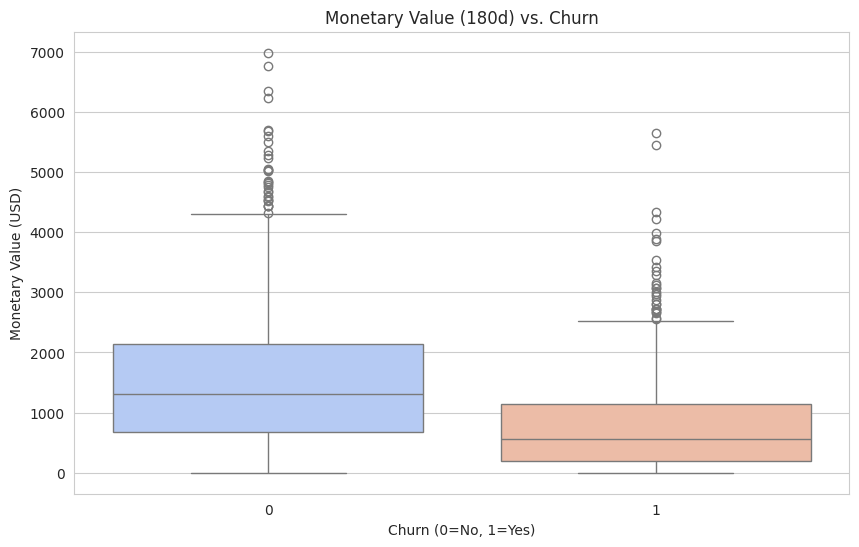

Mean Monetary Value for No Churn: 1554.7307776904947
Mean Monetary Value for Churn: 756.2195119787044


In [56]:


# Hypothesis 1: Customers with lower monetary value are more likely to churn.
plt.figure(figsize=(10, 6))
sns.boxplot(data=rmf, x='churn_next_60d', y='monetary_180d', palette='coolwarm')
plt.title('Monetary Value (180d) vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Monetary Value (USD)')
plt.show()

print("Mean Monetary Value for No Churn:",rmf[rmf['churn_next_60d'] == 0]['monetary_180d'].mean())
print("Mean Monetary Value for Churn:", rmf[rmf['churn_next_60d'] == 1]['monetary_180d'].mean())



### Hypothesis 2: Customers with higher recency (havent purchased for a long time) are more likely to churn.

**Explanation:** The box plot and mean values indicate that customers who churned have a higher `recency_days` (meaning more days since their last purchase) compared to non-churning customers. This aligns with the intuition that less recent activity is a churn indicator.

/tmp/ipykernel_7901/1249146133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rmf, x='churn_next_60d', y='recency_days', palette='coolwarm')


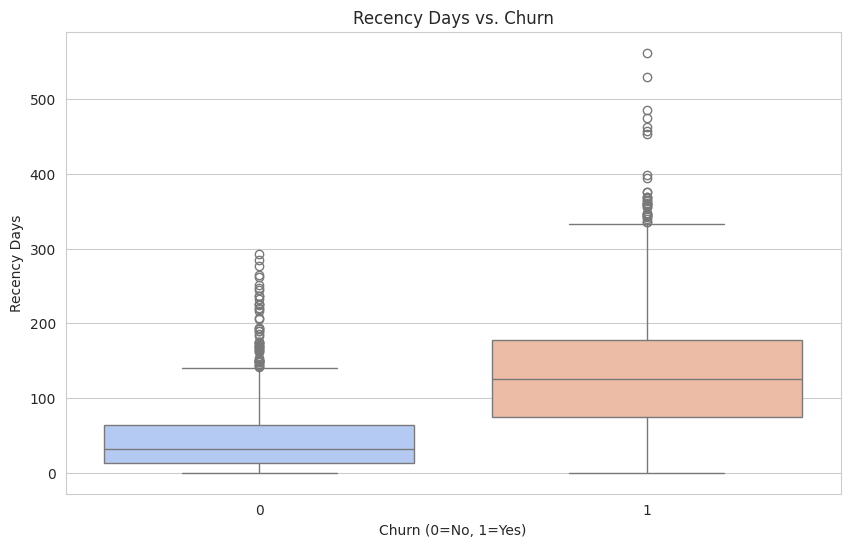

Mean Recency Days for No Churn: 45.07462686567164
Mean Recency Days for Churn: 135.15705412599823


In [57]:
# Hypothesis 2: Customers with higher recency (havent purchased recently) are more likely to churn.
plt.figure(figsize=(10, 6))
sns.boxplot(data=rmf, x='churn_next_60d', y='recency_days', palette='coolwarm')
plt.title('Recency Days vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Recency Days')
plt.show()

print("Mean Recency Days for No Churn:", rmf[rmf['churn_next_60d'] == 0]['recency_days'].mean())
print("Mean Recency Days for Churn:", rmf[rmf['churn_next_60d'] == 1]['recency_days'].mean())

### Hypothesis 3: Customers with fewer web sessions (less engagement in the last 30 days) are more likely to churn.

**Explanation:** The visualization shows that customers with fewer web sessions in the last 30 days are more prone to churn. Reduced online activity is a common precursor to churn, indicating decreased interest or engagement.

/tmp/ipykernel_7901/1358653012.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rmf, x='churn_next_60d', y='sessions_30d', palette='coolwarm')


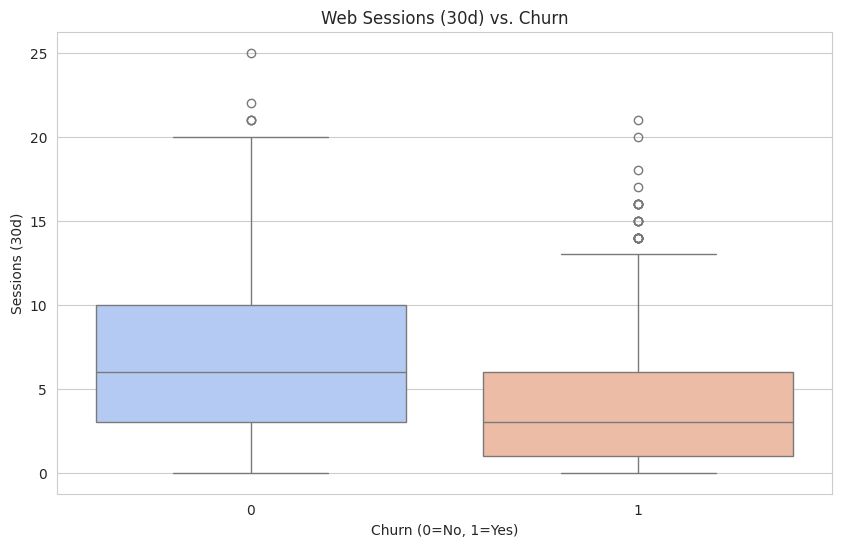

Mean Sessions (30d) for No Churn: 6.732128829536528
Mean Sessions (30d) for Churn: 4.0230700976042595


In [58]:
# Hypothesis 3: Customers with fewer web sessions (sessions_30d) are more likely to churn.
plt.figure(figsize=(10, 6))
sns.boxplot(data=rmf, x='churn_next_60d', y='sessions_30d', palette='coolwarm')
plt.title('Web Sessions (30d) vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Sessions (30d)')
plt.show()

print("Mean Sessions (30d) for No Churn:", rmf[rmf['churn_next_60d'] == 0]['sessions_30d'].mean())
print("Mean Sessions (30d) for Churn:", rmf[rmf['churn_next_60d'] == 1]['sessions_30d'].mean())

### Hypothesis 4: Customers with a lower average rating for their orders are more likely to churn.

**Explanation:** Consistently low ratings for purchased products suggest dissatisfaction with product quality or service, which can be a significant factor driving customers to churn. Higher average ratings would imply greater satisfaction and loyalty.

/tmp/ipykernel_7901/29196919.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rmf, x='churn_next_60d', y='avg_rating_180d', palette='coolwarm')


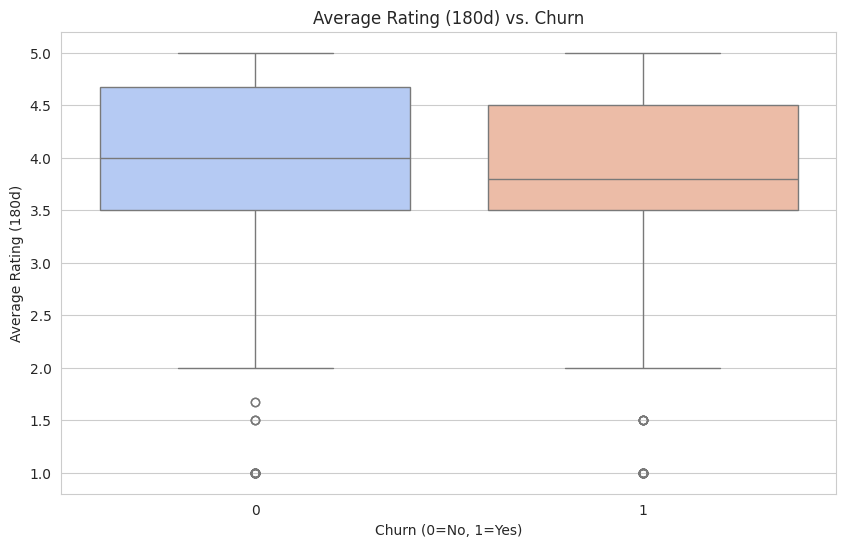

Mean Average Rating (180d) for No Churn: 3.910589159465829
Mean Average Rating (180d) for Churn: 3.775368234250222


In [59]:
# Hypothesis 4: Customers with a lower average rating for their orders are more likely to churn.
plt.figure(figsize=(10, 6))
sns.boxplot(data=rmf, x='churn_next_60d', y='avg_rating_180d', palette='coolwarm')
plt.title('Average Rating (180d) vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Average Rating (180d)')
plt.show()

print("Mean Average Rating (180d) for No Churn:", rmf[rmf['churn_next_60d'] == 0]['avg_rating_180d'].mean())
print("Mean Average Rating (180d) for Churn:", rmf[rmf['churn_next_60d'] == 1]['avg_rating_180d'].mean())

### Hypothesis 5: Customers with a higher return rate are more likely to churn.

**Explanation:** A high return rate could indicate dissatisfaction with products or a mismatch between expectation and reality, leading to a higher propensity to churn. Conversely, customers satisfied with their purchases are less likely to return items and thus less likely to churn.

/tmp/ipykernel_7901/3560857393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rmf, x='churn_next_60d', y='return_rate_180d', palette='coolwarm')


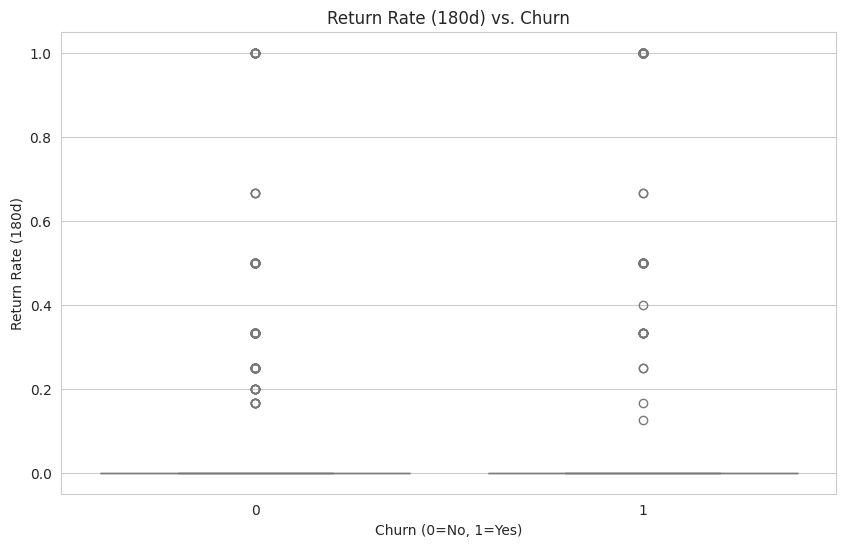

Mean Return Rate (180d) for No Churn: 0.04838098978790258
Mean Return Rate (180d) for Churn: 0.07632830523513752


In [60]:
# Hypothesis 5: Customers with a higher return rate are more likely to churn.
plt.figure(figsize=(10, 6))
sns.boxplot(data=rmf, x='churn_next_60d', y='return_rate_180d', palette='coolwarm')
plt.title('Return Rate (180d) vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Return Rate (180d)')
plt.show()

print("Mean Return Rate (180d) for No Churn:", rmf[rmf['churn_next_60d'] == 0]['return_rate_180d'].mean())
print("Mean Return Rate (180d) for Churn:", rmf[rmf['churn_next_60d'] == 1]['return_rate_180d'].mean())